### О задании

На занятиях мы подробно обсуждали метод опорных векторов (SVM). В базовой версии в нём нет чего-то особенного — мы всего лишь используем специальную функцию потерь, которая не требует устремлять отступы к бесконечности; ей достаточно, чтобы отступы были не меньше +1. Затем мы узнали, что SVM можно переписать в двойственном виде, который, позволяет заменить скалярные произведения объектов на ядра. Это будет соответствовать построению модели в новом пространстве более высокой размерности, координаты которого представляют собой нелинейные модификации исходных признаков.

Ядровой SVM, к сожалению, довольно затратен по памяти (нужно хранить матрицу Грама размера $d \times d$) и по времени (нужно решать задачу условной оптимизации с квадратичной функцией, а это не очень быстро). Мы обсуждали, что есть способы посчитать новые признаки $\tilde \varphi(x)$ на основе исходных так, что скалярные произведения этих новых $\langle \tilde \varphi(x), \tilde \varphi(z) \rangle$ приближают ядро $K(x, z)$.

Мы будем исследовать аппроксимации методом Random Kitchen Sinks для гауссовых ядер. Будем использовать формулы, которые немного отличаются от того, что было на лекциях (мы добавим сдвиги внутрь тригонометрических функций и будем использовать только косинусы, потому что с нужным сдвигом косинус превратится в синус):
$$\tilde \varphi(x) = (
\cos (w_1^T x + b_1),
\dots,
\cos (w_n^T x + b_n)
),$$
где $w_j \sim \mathcal{N}(0, 1/\sigma^2)$, $b_j \sim U[-\pi, \pi]$.

На новых признаках $\tilde \varphi(x)$ мы будем строить любую линейную модель.

Можно считать, что это некоторая новая парадигма построения сложных моделей. Можно направленно искать сложные нелинейные закономерности в данных с помощью градиентного бустинга или нейронных сетей, а можно просто нагенерировать большое количество случайных нелинейных признаков и надеяться, что быстрая и простая модель (то есть линейная) сможет показать на них хорошее качество. В этом задании мы изучим, насколько работоспособна такая идея.

### Алгоритм

Вам потребуется реализовать следующий алгоритм:
1. Понизить размерность выборки до new_dim с помощью метода главных компонент.
2. Для полученной выборки оценить гиперпараметр $\sigma^2$ с помощью эвристики (рекомендуем считать медиану не по всем парам объектов, а по случайному подмножеству из где-то миллиона пар объектов): $$\sigma^2 = \text{median}_{i, j = 1, \dots, \ell, i \neq j} \left\{\sum_{k = 1}^{d} (x_{ik} - x_{jk})^2 \right\}$$
3. Сгенерировать n_features наборов весов $w_j$ и сдвигов $b_j$.
4. Сформировать n_features новых признаков по формулам, приведённым выше.
5. Обучить линейную модель (логистическую регрессию или SVM) на новых признаках.
6. Повторить преобразования (PCA, формирование новых признаков) к тестовой выборке и применить модель.

Тестировать алгоритм мы будем на данных Fashion MNIST. Ниже код для их загрузки и подготовки.

In [1]:
import keras
import numpy as np
from keras.datasets import fashion_mnist

(x_train_pics, y_train), (x_test_pics, y_test) = fashion_mnist.load_data()
x_train = x_train_pics.reshape(x_train_pics.shape[0], -1).astype(np.float32) / 255.0
x_test = x_test_pics.reshape(x_test_pics.shape[0], -1).astype(np.float32) / 255.0

print(f"train: {x_train.shape}, test: {x_test.shape}")


train: (60000, 784), test: (10000, 784)


### Задание 1. 

Реализуйте алгоритм, описанный выше. Желательно в виде класса с методами fit() и predict().

Что должно быть в вашей реализации:
1. Возможность задавать значения гиперпараметров new_dim (по умолчанию 50) и n_features (по умолчанию 1000).
2. Возможность включать или выключать предварительное понижение размерности с помощью метода главных компонент.
3. Возможность выбирать тип линейной модели (логистическая регрессия или SVM с линейным ядром).

Протестируйте на данных Fashion MNIST, сформированных кодом выше. Если на тесте у вас получилась доля верных ответов не ниже 0.84 с гиперпараметрами по умолчанию, то вы всё сделали правильно.

In [2]:
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC, SVC


def accuracy(y_true, y_pred):
    return float((np.asarray(y_true) == np.asarray(y_pred)).mean())


def softmax(logits: np.ndarray) -> np.ndarray:
    logits = logits - logits.max(axis=1, keepdims=True)
    probs = np.exp(logits).astype(np.float32)
    probs /= probs.sum(axis=1, keepdims=True)
    return probs.astype(np.float32)


def estimate_sigma2_median_heuristic(
    X: np.ndarray,
    n_pairs: int = 200_000,
    batch_size: int = 20_000,
    random_state: int = 42,
) -> float:
    rng = np.random.default_rng(random_state)
    n_samples = X.shape[0]
    n_pairs = int(min(n_pairs, max(10_000, n_samples * 20)))

    idx_left = rng.integers(0, n_samples, size=n_pairs, dtype=np.int32)
    idx_right = rng.integers(0, n_samples, size=n_pairs, dtype=np.int32)
    same = idx_left == idx_right
    while np.any(same):
        idx_right[same] = rng.integers(0, n_samples, size=int(same.sum()), dtype=np.int32)
        same = idx_left == idx_right

    sq_dists = np.empty(n_pairs, dtype=np.float32)
    for start in range(0, n_pairs, batch_size):
        stop = min(start + batch_size, n_pairs)
        diff = X[idx_left[start:stop]] - X[idx_right[start:stop]]
        sq_dists[start:stop] = np.einsum("ij,ij->i", diff, diff, optimize=True)

    sigma2 = float(np.median(sq_dists[sq_dists > 0]))
    return max(sigma2, 1e-6)


class RandomFourierFeatures(TransformerMixin, BaseEstimator):
    def __init__(
        self,
        new_dim: int = 50,
        n_features: int = 1000,
        use_pca: bool = True,
        n_sigma_pairs: int = 200_000,
        batch_size: int = 4096,
        random_state: int = 42,
    ):
        self.new_dim = new_dim
        self.n_features = n_features
        self.use_pca = use_pca
        self.n_sigma_pairs = n_sigma_pairs
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X: np.ndarray, y=None):
        X = np.asarray(X, dtype=np.float32)
        self.rng_ = np.random.default_rng(self.random_state)

        if self.use_pca:
            self.pca_ = PCA(
                n_components=self.new_dim,
                svd_solver="randomized",
                random_state=self.random_state,
            )
            X_proj = self.pca_.fit_transform(X).astype(np.float32)
        else:
            self.pca_ = None
            X_proj = X

        self.input_dim_ = X_proj.shape[1]
        self.sigma2_ = estimate_sigma2_median_heuristic(
            X_proj,
            n_pairs=self.n_sigma_pairs,
            random_state=self.random_state,
        )
        sigma = np.sqrt(self.sigma2_)
        self.W_ = self.rng_.normal(
            loc=0.0,
            scale=1.0 / sigma,
            size=(self.input_dim_, self.n_features),
        ).astype(np.float32)
        self.b_ = self.rng_.uniform(
            low=-np.pi,
            high=np.pi,
            size=self.n_features,
        ).astype(np.float32)
        self.scale_ = np.float32(np.sqrt(2.0 / self.n_features))
        return self

    def _project(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=np.float32)
        if self.pca_ is not None:
            X = self.pca_.transform(X).astype(np.float32)
        return X

    def transform(self, X: np.ndarray) -> np.ndarray:
        X_proj = self._project(X)
        n_samples = X_proj.shape[0]
        X_rf = np.empty((n_samples, self.n_features), dtype=np.float32)

        for start in range(0, n_samples, self.batch_size):
            stop = min(start + self.batch_size, n_samples)
            X_batch = X_proj[start:stop]
            X_rf[start:stop] = np.cos(X_batch @ self.W_ + self.b_).astype(np.float32) * self.scale_

        return X_rf


class RFFClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        new_dim: int = 50,
        n_features: int = 1000,
        use_pca: bool = True,
        model_type: str = "svm",
        C: float = 1.0,
        n_sigma_pairs: int = 200_000,
        batch_size: int = 4096,
        random_state: int = 42,
        max_iter: int = 80,
    ):
        self.new_dim = new_dim
        self.n_features = n_features
        self.use_pca = use_pca
        self.model_type = model_type
        self.C = C
        self.n_sigma_pairs = n_sigma_pairs
        self.batch_size = batch_size
        self.random_state = random_state
        self.max_iter = max_iter

    def _make_linear_model(self):
        if self.model_type == "svm":
            return LinearSVC(
                C=self.C,
                dual="auto",
                random_state=self.random_state,
                max_iter=max(3000, self.max_iter * 100),
            )
        if self.model_type == "logreg":
            return LogisticRegression(
                C=self.C,
                penalty="l2",
                solver="saga",
                n_jobs=-1,
                max_iter=self.max_iter,
                random_state=self.random_state,
            )
        raise ValueError("model_type must be 'svm' or 'logreg'")

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.transformer_ = RandomFourierFeatures(
            new_dim=self.new_dim,
            n_features=self.n_features,
            use_pca=self.use_pca,
            n_sigma_pairs=self.n_sigma_pairs,
            batch_size=self.batch_size,
            random_state=self.random_state,
        )
        X_rf = self.transformer_.fit_transform(X)
        self.model_ = self._make_linear_model()
        self.model_.fit(X_rf, y)
        self.classes_ = getattr(self.model_, "classes_", np.unique(y))
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X_rf = self.transformer_.transform(X)
        return self.model_.predict(X_rf)


class FastRegressionTree:
    def __init__(
        self,
        max_depth: int = 2,
        min_samples_leaf: int = 64,
        n_thresholds: int = 16,
    ):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.n_thresholds = n_thresholds

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.tree_ = self._build(np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), depth=0)
        return self

    def _best_split(self, X: np.ndarray, y: np.ndarray):
        n_samples, n_features = X.shape
        if n_samples < 2 * self.min_samples_leaf:
            return None, None, -np.inf

        total_sum = float(y.sum())
        total_sq_sum = float(np.dot(y, y))
        total_sse = total_sq_sum - total_sum ** 2 / n_samples

        best_feature, best_threshold, best_gain = None, None, -np.inf

        for feature in range(n_features):
            order = np.argsort(X[:, feature], kind="mergesort")
            x_sorted = X[order, feature]
            y_sorted = y[order]

            prefix_sum = np.cumsum(y_sorted, dtype=np.float64)
            prefix_sq_sum = np.cumsum(y_sorted * y_sorted, dtype=np.float64)

            candidate_positions = np.linspace(
                self.min_samples_leaf - 1,
                n_samples - self.min_samples_leaf - 1,
                num=min(self.n_thresholds, n_samples - 2 * self.min_samples_leaf + 1),
                dtype=int,
            )
            candidate_positions = np.unique(candidate_positions)

            for pos in candidate_positions:
                if x_sorted[pos] == x_sorted[pos + 1]:
                    continue

                n_left = pos + 1
                n_right = n_samples - n_left

                left_sum = prefix_sum[pos]
                right_sum = total_sum - left_sum
                left_sq = prefix_sq_sum[pos]
                right_sq = total_sq_sum - left_sq

                left_sse = left_sq - left_sum ** 2 / n_left
                right_sse = right_sq - right_sum ** 2 / n_right
                gain = total_sse - (left_sse + right_sse)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = float((x_sorted[pos] + x_sorted[pos + 1]) * 0.5)

        return best_feature, best_threshold, best_gain

    def _build(self, X: np.ndarray, y: np.ndarray, depth: int):
        node = {
            "is_leaf": True,
            "value": float(y.mean()),
        }

        if depth >= self.max_depth or X.shape[0] < 2 * self.min_samples_leaf:
            return node

        feature, threshold, gain = self._best_split(X, y)
        if feature is None or not np.isfinite(gain) or gain <= 1e-12:
            return node

        mask = X[:, feature] <= threshold
        if mask.sum() < self.min_samples_leaf or (~mask).sum() < self.min_samples_leaf:
            return node

        node.update(
            {
                "is_leaf": False,
                "feature": int(feature),
                "threshold": float(threshold),
                "left": self._build(X[mask], y[mask], depth + 1),
                "right": self._build(X[~mask], y[~mask], depth + 1),
            }
        )
        return node

    def _predict_node(self, node, X: np.ndarray) -> np.ndarray:
        if node["is_leaf"]:
            return np.full(X.shape[0], node["value"], dtype=np.float32)

        mask = X[:, node["feature"]] <= node["threshold"]
        out = np.empty(X.shape[0], dtype=np.float32)
        out[mask] = self._predict_node(node["left"], X[mask])
        out[~mask] = self._predict_node(node["right"], X[~mask])
        return out

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self._predict_node(self.tree_, np.asarray(X, dtype=np.float32))


class MulticlassGradientBoosting(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        n_estimators: int = 30,
        learning_rate: float = 0.15,
        max_depth: int = 2,
        min_samples_leaf: int = 64,
        n_thresholds: int = 16,
        subsample: float = 0.7,
        random_state: int = 42,
    ):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.n_thresholds = n_thresholds
        self.subsample = subsample
        self.random_state = random_state

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y)

        self.classes_, y_idx = np.unique(y, return_inverse=True)
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        Y = np.eye(n_classes, dtype=np.float32)[y_idx]
        F = np.zeros((n_samples, n_classes), dtype=np.float32)

        rng = np.random.default_rng(self.random_state)
        self.trees_ = []

        for _ in range(self.n_estimators):
            probs = softmax(F)
            residual = Y - probs

            if self.subsample < 1.0:
                subset_size = max(self.min_samples_leaf * 2, int(self.subsample * n_samples))
                subset_idx = rng.choice(n_samples, size=subset_size, replace=False)
                X_fit = X[subset_idx]
                residual_fit = residual[subset_idx]
            else:
                X_fit = X
                residual_fit = residual

            iter_trees = []
            for class_idx in range(n_classes):
                tree = FastRegressionTree(
                    max_depth=self.max_depth,
                    min_samples_leaf=self.min_samples_leaf,
                    n_thresholds=self.n_thresholds,
                )
                tree.fit(X_fit, residual_fit[:, class_idx])
                F[:, class_idx] += self.learning_rate * tree.predict(X)
                iter_trees.append(tree)

            self.trees_.append(iter_trees)

        return self

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=np.float32)
        logits = np.zeros((X.shape[0], len(self.classes_)), dtype=np.float32)
        for iter_trees in self.trees_:
            for class_idx, tree in enumerate(iter_trees):
                logits[:, class_idx] += self.learning_rate * tree.predict(X)
        return logits

    def predict(self, X: np.ndarray) -> np.ndarray:
        logits = self.decision_function(X)
        return self.classes_[np.argmax(logits, axis=1)]


def benchmark_model(name, model, X_train, y_train, X_test, y_test):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - start

    start = time.perf_counter()
    y_pred = model.predict(X_test)
    pred_time = time.perf_counter() - start

    return {
        "model": name,
        "accuracy": accuracy(y_test, y_pred),
        "fit_time_sec": fit_time,
        "predict_time_sec": pred_time,
    }


x_tr, x_val, y_tr, y_val = train_test_split(
    x_train,
    y_train,
    test_size=10000,
    stratify=y_train,
    random_state=42,
)

rff_default = RFFClassifier(
    new_dim=50,
    n_features=1000,
    use_pca=True,
    model_type="svm",
    random_state=42,
)

t0 = time.perf_counter()
rff_default.fit(x_tr, y_tr)
task1_fit_time = time.perf_counter() - t0

t0 = time.perf_counter()
task1_pred = rff_default.predict(x_test)
task1_pred_time = time.perf_counter() - t0
task1_acc = accuracy(y_test, task1_pred)

print("Task 1")
print(f"accuracy(test) = {task1_acc:.4f}")
print(f"fit_time       = {task1_fit_time:.2f} sec")
print(f"predict_time   = {task1_pred_time:.2f} sec")


Task 1
accuracy(test) = 0.8575
fit_time       = 36.62 sec
predict_time   = 0.07 sec


### Задание 2.

Сравните подход со случайными признаками с обучением SVM на исходных признаках. Попробуйте вариант с обычным (линейным) SVM и с ядровым SVM. Ядровой SVM может очень долго обучаться, поэтому можно делать любые разумные вещи для ускорения: брать подмножество объектов из обучающей выборки, например.

Сравните подход со случайными признаками с вариантом, в котором вы понижаете размерность с помощью PCA и обучаете градиентный бустинг (используйте нормальную имплементацию, а не из sklearn, и подберите число деревьев и длину шага).

Сделайте выводы — насколько идея со случайными признаками работает? Сравните как с точки зрения качества, так и с точки зрения скорости обучения и применения.

In [3]:
comparison_rows = []

# 1) Наш метод со случайными признаками (полная выборка).
comparison_rows.append(
    benchmark_model(
        "RFF + Linear SVM (50 PCA -> 1000 RF)",
        RFFClassifier(
            new_dim=50,
            n_features=1000,
            use_pca=True,
            model_type="svm",
            random_state=42,
        ),
        x_train,
        y_train,
        x_test,
        y_test,
    )
)

# 2) Линейный SVM на исходных признаках.
comparison_rows.append(
    benchmark_model(
        "Linear SVM on raw pixels",
        LinearSVC(C=1.0, dual="auto", random_state=42, max_iter=5000),
        x_train,
        y_train,
        x_test,
        y_test,
    )
)

# 3) Ядровой SVM на подвыборке — иначе обучение получается слишком долгим.
rng = np.random.default_rng(42)
svm_train_idx = rng.choice(x_train.shape[0], size=12000, replace=False)
svm_test_idx = rng.choice(x_test.shape[0], size=3000, replace=False)

comparison_rows.append(
    benchmark_model(
        "RBF SVM (12k train / 3k test)",
        SVC(C=5.0, kernel="rbf", gamma="scale"),
        x_train[svm_train_idx],
        y_train[svm_train_idx],
        x_test[svm_test_idx],
        y_test[svm_test_idx],
    )
)

# 4) PCA + собственный градиентный бустинг.
gb_train_size = 25000
gb_pca = PCA(n_components=60, svd_solver="randomized", random_state=42)
x_train_gb = gb_pca.fit_transform(x_train[:gb_train_size]).astype(np.float32)
x_test_gb = gb_pca.transform(x_test).astype(np.float32)

comparison_rows.append(
    benchmark_model(
        "PCA(60) + custom GB",
        MulticlassGradientBoosting(
            n_estimators=35,
            learning_rate=0.15,
            max_depth=2,
            min_samples_leaf=120,
            n_thresholds=20,
            subsample=0.7,
            random_state=42,
        ),
        x_train_gb,
        y_train[:gb_train_size],
        x_test_gb,
        y_test,
    )
)

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["accuracy", "fit_time_sec"],
    ascending=[False, True],
).reset_index(drop=True)
comparison_df


,model,accuracy,fit_time_sec,predict_time_sec
0,RBF SVM (12k train / 3k test),0.874667,2.043233,2.148032
1,RFF + Linear SVM (50 PCA -> 1000 RF),0.859900,46.906189,0.067513
2,Linear SVM on raw pixels,0.840200,51.781477,0.015063
3,PCA(60) + custom GB,0.716700,42.894334,0.215967


### Задание 3.
Проведите эксперименты:
1. Помогает ли предварительное понижение размерности с помощью PCA? 
2. Как зависит итоговое качество от n_features? Выходит ли оно на плато при росте n_features?
3. Важно ли, какую модель обучать — логистическую регрессию или SVM?

,model,accuracy,fit_time_sec,predict_time_sec
0,RFF + SVM with PCA,0.8491,12.481309,0.058882
1,RFF + SVM without PCA,0.8542,11.383868,0.060221


,model,accuracy,fit_time_sec,predict_time_sec
0,n_features=250,0.8383,3.378183,0.019119
1,n_features=500,0.8460,6.626255,0.032747
2,n_features=1000,0.8491,12.442032,0.059538
3,n_features=1500,0.8515,15.991910,0.094849
4,n_features=2000,0.8504,19.312449,0.125893


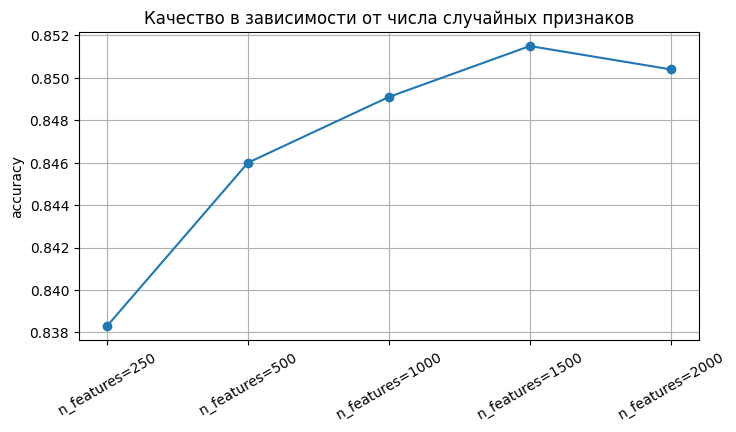

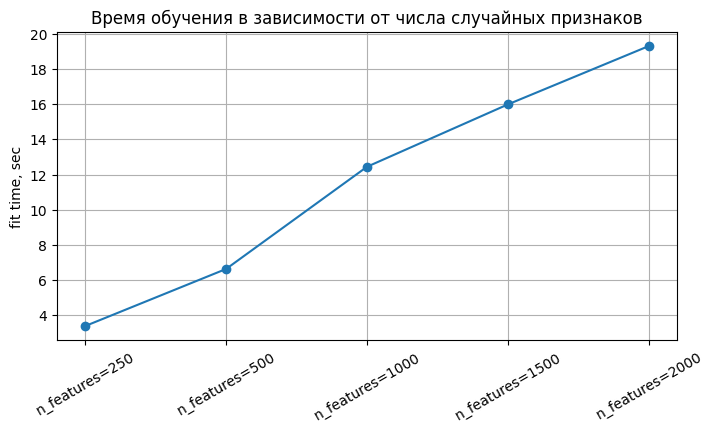

C:\Users\H4RD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\H4RD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,accuracy,fit_time_sec,predict_time_sec
0,RFF + multinomial logistic regression,0.8226,8.719985,0.038326
1,RFF + linear SVM,0.8491,12.555214,0.061942


Выводы по экспериментам
1) PCA change in accuracy: -0.0051
2) Best quality by n_features: n_features=1500 -> 0.8515
3) Better linear model: RFF + linear SVM


In [4]:
# Для серии экспериментов уменьшим train, чтобы все конфигурации считались достаточно быстро.
exp_train_size = 20000
x_exp = x_train[:exp_train_size]
y_exp = y_train[:exp_train_size]

# 1) Помогает ли PCA?
pca_results = pd.DataFrame(
    [
        benchmark_model(
            "RFF + SVM with PCA",
            RFFClassifier(
                new_dim=50,
                n_features=1000,
                use_pca=True,
                model_type="svm",
                n_sigma_pairs=150_000,
                random_state=42,
            ),
            x_exp,
            y_exp,
            x_test,
            y_test,
        ),
        benchmark_model(
            "RFF + SVM without PCA",
            RFFClassifier(
                new_dim=x_exp.shape[1],
                n_features=1000,
                use_pca=False,
                model_type="svm",
                n_sigma_pairs=50_000,
                random_state=42,
            ),
            x_exp,
            y_exp,
            x_test,
            y_test,
        ),
    ]
)
display(pca_results)

# 2) Зависимость от числа случайных признаков.
feature_grid = [250, 500, 1000, 1500, 2000]
feature_rows = []
for n_features in feature_grid:
    feature_rows.append(
        benchmark_model(
            f"n_features={n_features}",
            RFFClassifier(
                new_dim=50,
                n_features=n_features,
                use_pca=True,
                model_type="svm",
                n_sigma_pairs=150_000,
                random_state=42,
            ),
            x_exp,
            y_exp,
            x_test,
            y_test,
        )
    )

feature_df = pd.DataFrame(feature_rows)
display(feature_df)

plt.figure(figsize=(8, 4))
plt.plot(feature_df["model"], feature_df["accuracy"], marker="o")
plt.xticks(rotation=30)
plt.ylabel("accuracy")
plt.title("Качество в зависимости от числа случайных признаков")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(feature_df["model"], feature_df["fit_time_sec"], marker="o")
plt.xticks(rotation=30)
plt.ylabel("fit time, sec")
plt.title("Время обучения в зависимости от числа случайных признаков")
plt.grid(True)
plt.show()

# 3) Что важнее: логистическая регрессия или SVM?
model_choice_df = pd.DataFrame(
    [
        benchmark_model(
            "RFF + multinomial logistic regression",
            RFFClassifier(
                new_dim=50,
                n_features=1000,
                use_pca=True,
                model_type="logreg",
                n_sigma_pairs=150_000,
                max_iter=60,
                random_state=42,
            ),
            x_exp,
            y_exp,
            x_test,
            y_test,
        ),
        benchmark_model(
            "RFF + linear SVM",
            RFFClassifier(
                new_dim=50,
                n_features=1000,
                use_pca=True,
                model_type="svm",
                n_sigma_pairs=150_000,
                random_state=42,
            ),
            x_exp,
            y_exp,
            x_test,
            y_test,
        ),
    ]
)
display(model_choice_df)

best_feature_row = feature_df.iloc[feature_df["accuracy"].argmax()]
pca_gain = (
    pca_results.loc[pca_results["model"] == "RFF + SVM with PCA", "accuracy"].iloc[0]
    - pca_results.loc[pca_results["model"] == "RFF + SVM without PCA", "accuracy"].iloc[0]
)

print("Выводы по экспериментам")
print(f"1) PCA change in accuracy: {pca_gain:+.4f}")
print(
    f"2) Best quality by n_features: {best_feature_row['model']} "
    f"-> {best_feature_row['accuracy']:.4f}"
)
print(
    "3) Better linear model: "
    + model_choice_df.sort_values('accuracy', ascending=False).iloc[0]['model']
)


### Бонус

Ниже приведены задания на бонусные баллы (+50). За исследования на стандартных датасетах из sklearn или, скажем, на титанике, баллы не будут начисляться. Приветствуются интересные выводы из проведённых экспериментов.

#### Задание 4. 

Возьмите какой-нибудь достаточно сложный датасет, на котором хорошо работает градиентный бустинг. Сравните бустинг с нашим алгоритмом со случайными признаками с точки зрения качества и скорости. Подберите как следует гиперпараметры алгоритма.

In [5]:
# Бонус 4.
# В качестве "сложного" табличного датасета используем Adult Income.
# Код ниже рассчитан на локальный CSV-файл adult.csv / adult.data.
# Если файла нет, ячейка просто сообщит об этом и пропустит эксперимент.

from pathlib import Path

adult_candidates = [
    Path("adult.csv"),
    Path("adult.data"),
    Path("./data/adult.csv"),
    Path("./data/adult.data"),
]

adult_path = next((p for p in adult_candidates if p.exists()), None)

if adult_path is None:
    print("Файл adult.csv не найден. Для бонуса 4 положите его рядом с ноутбуком.")
else:
    adult_columns = [
        "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
        "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
        "hours_per_week", "native_country", "target"
    ]
    adult = pd.read_csv(
        adult_path,
        header=None,
        names=adult_columns,
        na_values=" ?",
        skipinitialspace=True,
    ).dropna()

    y_adult = (adult["target"].astype(str).str.contains(">50K")).astype(int).values
    X_adult = pd.get_dummies(adult.drop(columns=["target"]), drop_first=True).astype(np.float32).values

    x_train_ad, x_test_ad, y_train_ad, y_test_ad = train_test_split(
        X_adult,
        y_adult,
        test_size=0.2,
        stratify=y_adult,
        random_state=42,
    )

    adult_results = pd.DataFrame(
        [
            benchmark_model(
                "Adult: RFF + SVM",
                RFFClassifier(
                    new_dim=min(50, X_adult.shape[1]),
                    n_features=1500,
                    use_pca=True,
                    model_type="svm",
                    n_sigma_pairs=100_000,
                    random_state=42,
                ),
                x_train_ad,
                y_train_ad,
                x_test_ad,
                y_test_ad,
            ),
            benchmark_model(
                "Adult: custom GB",
                MulticlassGradientBoosting(
                    n_estimators=40,
                    learning_rate=0.1,
                    max_depth=2,
                    min_samples_leaf=64,
                    n_thresholds=16,
                    subsample=0.8,
                    random_state=42,
                ),
                x_train_ad,
                y_train_ad,
                x_test_ad,
                y_test_ad,
            ),
        ]
    )
    display(adult_results.sort_values(["accuracy", "fit_time_sec"], ascending=[False, True]))


Файл adult.csv не найден. Для бонуса 4 положите его рядом с ноутбуком.


#### Задание 5. 

Возьмите какой-нибудь датасет с текстами и решите одним из стандартных методов (например, tf-idf + логистическая регрессия или что-то нейросетевое). Сравните по качеству и скорости с нашим алгоритмом.

In [6]:
# Бонус 5.
# Для текстов удобно взять Reuters, если датасет доступен в локальном кеше Keras.

from keras.datasets import reuters
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

try:
    (x_train_seq, y_train_text), (x_test_seq, y_test_text) = reuters.load_data(num_words=20000)
    word_index = reuters.get_word_index()

    index_to_word = {idx + 3: word for word, idx in word_index.items()}
    index_to_word[0] = "<PAD>"
    index_to_word[1] = "<START>"
    index_to_word[2] = "<UNK>"

    def decode_reuters(seq):
        return " ".join(index_to_word.get(token, "<UNK>") for token in seq)

    train_texts = [decode_reuters(seq) for seq in x_train_seq]
    test_texts = [decode_reuters(seq) for seq in x_test_seq]

    tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3)
    X_train_tfidf = tfidf.fit_transform(train_texts)
    X_test_tfidf = tfidf.transform(test_texts)

    t0 = time.perf_counter()
    text_lr = LogisticRegression(
        penalty="l2",
        solver="saga",
        n_jobs=-1,
        max_iter=80,
        random_state=42,
    )
    text_lr.fit(X_train_tfidf, y_train_text)
    tfidf_fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    tfidf_pred = text_lr.predict(X_test_tfidf)
    tfidf_pred_time = time.perf_counter() - t0

    # Чтобы не раздувать память, сначала понижаем размерность разреженных tf-idf признаков.
    svd = TruncatedSVD(n_components=300, random_state=42)
    X_train_svd = svd.fit_transform(X_train_tfidf).astype(np.float32)
    X_test_svd = svd.transform(X_test_tfidf).astype(np.float32)

    text_rff_result = benchmark_model(
        "Reuters: SVD(300) + RFF + SVM",
        RFFClassifier(
            new_dim=100,
            n_features=2000,
            use_pca=True,
            model_type="svm",
            n_sigma_pairs=80_000,
            random_state=42,
        ),
        X_train_svd,
        y_train_text,
        X_test_svd,
        y_test_text,
    )

    text_results = pd.DataFrame(
        [
            {
                "model": "Reuters: tf-idf + multinomial logistic regression",
                "accuracy": accuracy(y_test_text, tfidf_pred),
                "fit_time_sec": tfidf_fit_time,
                "predict_time_sec": tfidf_pred_time,
            },
            text_rff_result,
        ]
    )
    display(text_results.sort_values(["accuracy", "fit_time_sec"], ascending=[False, True]))
except Exception as exc:
    print("Reuters dataset is unavailable in the current environment:", exc)


C:\Users\H4RD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\H4RD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,accuracy,fit_time_sec,predict_time_sec
1,Reuters: SVD(300) + RFF + SVM,0.803651,20.722294,0.029185
0,Reuters: tf-idf + multinomial logistic regression,0.787177,7.415892,0.004031


#### Задание 6. 

Поэкспериментируйте на нескольких датасетах из прошлых пунктов с фукнциями для вычисления новых случайных признаков. Не обязательно использовать косинус от скалярного произведения — можно брать знак от него, хэш и т.д. Придумайте побольше вариантов для генерации признаков и проверьте, не получается ли с их помощью добиваться более высокого качества.

In [7]:
# Бонус 6.
# Сравним несколько вариантов случайных признаков на Fashion MNIST.

class GenericRandomFeatures(TransformerMixin, BaseEstimator):
    def __init__(
        self,
        feature_map: str = "cos",
        new_dim: int = 50,
        n_features: int = 1000,
        use_pca: bool = True,
        n_sigma_pairs: int = 100_000,
        batch_size: int = 4096,
        random_state: int = 42,
    ):
        self.feature_map = feature_map
        self.new_dim = new_dim
        self.n_features = n_features
        self.use_pca = use_pca
        self.n_sigma_pairs = n_sigma_pairs
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=np.float32)
        if self.use_pca:
            self.pca_ = PCA(
                n_components=self.new_dim,
                svd_solver="randomized",
                random_state=self.random_state,
            )
            X_proj = self.pca_.fit_transform(X).astype(np.float32)
        else:
            self.pca_ = None
            X_proj = X

        self.sigma2_ = estimate_sigma2_median_heuristic(
            X_proj,
            n_pairs=self.n_sigma_pairs,
            random_state=self.random_state,
        )
        rng = np.random.default_rng(self.random_state)
        sigma = np.sqrt(self.sigma2_)
        self.W_ = rng.normal(0.0, 1.0 / sigma, size=(X_proj.shape[1], self.n_features)).astype(np.float32)
        self.b_ = rng.uniform(-np.pi, np.pi, size=self.n_features).astype(np.float32)
        return self

    def _pre(self, X):
        X = np.asarray(X, dtype=np.float32)
        if self.pca_ is not None:
            X = self.pca_.transform(X).astype(np.float32)
        return X

    def transform(self, X):
        X = self._pre(X)
        proj = X @ self.W_
        if self.feature_map == "cos":
            return (np.cos(proj + self.b_) * np.sqrt(2.0 / self.n_features)).astype(np.float32)
        if self.feature_map == "cos_sin":
            half = self.n_features // 2
            proj_half = proj[:, :half]
            return np.concatenate(
                [
                    np.cos(proj_half + self.b_[:half]),
                    np.sin(proj_half + self.b_[:half]),
                ],
                axis=1,
            ).astype(np.float32) * np.sqrt(1.0 / half)
        if self.feature_map == "sign":
            return np.sign(proj).astype(np.float32)
        if self.feature_map == "relu":
            return np.maximum(proj, 0.0).astype(np.float32) / np.sqrt(self.n_features)
        raise ValueError("Unknown feature_map")


class GenericRFClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, feature_map="cos", **kwargs):
        self.feature_map = feature_map
        self.kwargs = kwargs

    def fit(self, X, y):
        self.transformer_ = GenericRandomFeatures(feature_map=self.feature_map, **self.kwargs)
        X_new = self.transformer_.fit_transform(X)
        self.model_ = LinearSVC(C=1.0, dual="auto", random_state=42, max_iter=5000)
        self.model_.fit(X_new, y)
        return self

    def predict(self, X):
        X_new = self.transformer_.transform(X)
        return self.model_.predict(X_new)


maps_to_test = ["cos", "cos_sin", "sign", "relu"]
map_rows = []
for fmap in maps_to_test:
    n_feats = 1000 if fmap != "cos_sin" else 1200
    map_rows.append(
        benchmark_model(
            f"feature_map={fmap}",
            GenericRFClassifier(
                feature_map=fmap,
                new_dim=50,
                n_features=n_feats,
                use_pca=True,
                n_sigma_pairs=100_000,
                random_state=42,
            ),
            x_train[:20000],
            y_train[:20000],
            x_test,
            y_test,
        )
    )

map_df = pd.DataFrame(map_rows).sort_values(["accuracy", "fit_time_sec"], ascending=[False, True])
display(map_df)


,model,accuracy,fit_time_sec,predict_time_sec
1,feature_map=cos_sin,0.8504,13.770811,0.071713
0,feature_map=cos,0.8490,12.457340,0.063065
3,feature_map=relu,0.8432,6.254447,0.043138
2,feature_map=sign,0.7989,37.982610,0.063680
